In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
import xarray as xr

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from neuralop.models.local_no import LocalNO
from neuralop.models import UNO
from neuralop.layers.spectral_convolution import SpectralConv

from tabulate import tabulate

torch.serialization.add_safe_globals([torch.nn.functional.gelu])

In [ ]:
class ContinuousBasisConv3d(nn.Module):
    def __init__(self, channels, radii=[1, 2, 3], num_bases=12, h=1.0, is_differential=False, basis_type='rbf'):
        super().__init__()
        self.channels = channels
        self.radii = radii
        self.num_bases = num_bases
        self.h = h
        self.is_differential = is_differential
        self.basis_type = basis_type 
        
        max_r = max(radii)
        self.padding = (0, max_r, max_r) 

        grid_t, grid_y, grid_x = torch.meshgrid(
            torch.arange(0, 1),
            torch.arange(-max_r, max_r + 1),
            torch.arange(-max_r, max_r + 1),
            indexing='ij'
        )
        self.register_buffer('grid_t', grid_t.float())
        self.register_buffer('grid_y', grid_y.float())
        self.register_buffer('grid_x', grid_x.float())

        self.time_scale = nn.Parameter(torch.tensor(1.0))
        
        init_p =[]
        for i in range(num_bases):
            init_p.append(radii[i % len(radii)])
            
        self.basis_params = nn.Parameter(torch.tensor(init_p, dtype=torch.float32))
        
        fan_in = channels * (1 * (2*max_r+1) * (2*max_r+1))
        std = (2.0 / fan_in) ** 0.5
        self.basis_weights = nn.Parameter(torch.randn(channels, channels, num_bases) * std)

    def generate_kernel(self):
        dx = self.grid_x * self.h
        dy = self.grid_y * self.h
        dt = self.grid_t * self.time_scale
        r_sq = dt**2 + dx**2 + dy**2
        r = torch.sqrt(r_sq + 1e-8)
    
        params = torch.clamp(torch.abs(self.basis_params), min=0.1)
        p = params.view(-1, 1, 1, 1)
    
        half = self.num_bases // 2
        
        if self.basis_type == 'rbf':
            base_1 = torch.exp(-(r_sq.unsqueeze(0) / (p[:half]**2)))
        elif self.basis_type == 'wendland':
            r_norm = r.unsqueeze(0) / p[:half]
            relu_part = F.relu(1.0 - r_norm)
            base_1 = (relu_part ** 4) * (4 * r_norm + 1.0)
            
        base_2 = F.relu(1.0 - (r.unsqueeze(0) / p[half:]))
        
        bases_tensor = torch.cat([base_1, base_2], dim=0)
        kernel = torch.einsum('oib, btyx -> oityx', self.basis_weights, bases_tensor)
        kernel = kernel / np.sqrt(self.num_bases)
        
        if self.is_differential:
            kernel_mean = kernel.mean(dim=(2, 3, 4), keepdim=True)
            kernel = kernel - kernel_mean
            kernel = kernel / (self.h + 1e-8)
            
        return kernel

    def forward(self, x):
        weight = self.generate_kernel()
        
        if weight.shape[2] == 1:
            B, C, T, Y, X = x.shape
            
            weight_2d = weight.squeeze(2)
            
            x_2d = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, Y, X)
            
            pad_y, pad_x = self.padding[1], self.padding[2]
            out_2d = F.conv2d(x_2d, weight_2d, bias=None, padding=(pad_y, pad_x))
            
            out = out_2d.reshape(B, T, self.channels, Y, X).permute(0, 2, 1, 3, 4)
            return out
        else:
            return F.conv3d(x, weight, bias=None, padding=self.padding)

In [3]:
class TrueLocalNOBlock3d(nn.Module):
    def __init__(self, channels, modes, radii=[1, 2, 3, 5], num_bases=12, basis_type='rbf'):
        super().__init__()
        self.fno_conv = SpectralConv(in_channels=channels, out_channels=channels, n_modes=modes)
        
        self.local_integral = ContinuousBasisConv3d(
            channels, 
            radii=radii, 
            num_bases=num_bases, 
            is_differential=False,
            basis_type=basis_type
        )
        
        self.local_differential = ContinuousBasisConv3d(
            channels, 
            radii=radii, 
            num_bases=num_bases, 
            is_differential=True, 
            basis_type=basis_type
        )
        
        self.skip = nn.Conv3d(channels, channels, kernel_size=1)
        self.norm = nn.InstanceNorm3d(channels)
        self.activation = nn.GELU()
        self.fusion_weights = nn.Parameter(torch.ones(4)) 

    def forward(self, x, mask=None):
        identity = x 
        w = torch.softmax(self.fusion_weights, dim=0)
        
        out_fno = self.fno_conv(x)
        out_int = self.local_integral(x)
        out_diff = self.local_differential(x)
        out_skip = self.skip(x)
        
        out = (w[0] * out_fno + w[1] * out_int + w[2] * out_diff + w[3] * out_skip)
        out = self.norm(identity + out)
        
        if mask is not None:
            out = out * mask
        return self.activation(out)


class CustomLocalNO3d(nn.Module):
    def __init__(self, 
                 in_channels=2, 
                 out_channels=1, 
                 hidden_channels=32,
                 n_layers=4, 
                 modes=(10, 20, 20), 
                 radii=[1, 2, 3, 5], 
                 num_bases=12, 
                 basis_type='rbf'
    ):
        super().__init__()
        self.lift = nn.Conv3d(in_channels, hidden_channels, kernel_size=1)
        
        self.blocks = nn.ModuleList([
            TrueLocalNOBlock3d(channels=hidden_channels, 
                               modes=modes, 
                               radii=radii, 
                               num_bases=num_bases, 
                               basis_type=basis_type
            ) for _ in range(n_layers)]
        )
        
        self.project = nn.Sequential(
            nn.Conv3d(hidden_channels, hidden_channels, kernel_size=1),
            nn.GELU(),
            nn.Conv3d(hidden_channels, out_channels, kernel_size=1)
        )

    def forward(self, x, mask=None):
        x = self.lift(x)
        if mask is not None: x = x * mask
        for block in self.blocks:
            x = block(x, mask=mask)
        x = self.project(x)
        return x

In [4]:
CURRENT_DIRECTORY = f'horizontal_correct/'
DATA_PATH = f'data'
ASSETS_PATH = f'assets'
MODELS_PATH = f'models'

filepaths =[f'{DATA_PATH}/source_{i}.hdf5' for i in range(1, 4)]

dim_map = {
    'phony_dim_0' : 'time',
    'phony_dim_1' : 'sample',
    'phony_dim_2' : 'channel',
    'phony_dim_3' : 'Y',
    'phony_dim_4' : 'X'
}

In [5]:
def preprocess(path):
    print(f'Открытие датасета : {path}')
    ds = xr.open_dataset(path, engine='h5netcdf', phony_dims='sort').rename(dim_map)
    pressure = ds.dataset.isel(channel=0)
    source = ds.source
    return xr.Dataset({'pressure': pressure, 'source':source}, attrs=ds.attrs)

print("Загрузка данных...")
processed_datasets = [preprocess(f) for f in filepaths]
final_ds = xr.concat(processed_datasets, dim='sample').squeeze('phony_dim_5')

Загрузка данных...
Открытие датасета : data/source_1.hdf5
Открытие датасета : data/source_2.hdf5
Открытие датасета : data/source_3.hdf5


In [ ]:
raw_p = final_ds.pressure.values
mask_2d = ~np.isnan(raw_p[0, 0])

p_min, p_max = np.nanmin(raw_p), np.nanmax(raw_p)
norm_p = np.zeros_like(raw_p, dtype='float32')
norm_p[:, :, mask_2d] = (raw_p[:, :, mask_2d] - p_min) / (p_max - p_min)

s_raw = final_ds.source.values.copy()
s_raw[..., ~mask_2d] = 0 
s_abs_max = np.max(np.abs(s_raw))
norm_s = (s_raw / s_abs_max).astype('float32') if s_abs_max != 0 else s_raw

In [7]:
P_tensor = torch.from_numpy(norm_p).permute(1, 0, 2, 3).float()
S_tensor = torch.from_numpy(norm_s).float()
X_final = torch.stack([P_tensor, S_tensor], dim=2)
STATIC_MASK = torch.from_numpy(mask_2d.astype('float32'))

In [8]:
def get_indices(size, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    np.random.seed(2318)
    indices = np.arange(size)
    np.random.shuffle(indices)
    train_end = int(size * train_ratio)
    val_end = train_end + int(size * val_ratio)
    return indices[:train_end], indices[train_end:val_end], indices[val_end:]

In [9]:
class SpatiotemporalDataset(Dataset):
    def __init__(self, data, indices):
        self.data = data[indices] 
        self.N_samples = self.data.shape[0]
        self.T_total = self.data.shape[1]
        self.T_future = self.T_total - 1

    def __len__(self):
        return self.N_samples

    def __getitem__(self, idx):
        p_init = self.data[idx, 0, 0] 
        p_init_cube = p_init.unsqueeze(0).repeat(self.T_future, 1, 1)
        s_future_cube = self.data[idx, 1:, 1]
        x = torch.stack([p_init_cube, s_future_cube], dim=0)
        y = self.data[idx, 1:, 0].unsqueeze(0)
        return x, y

In [23]:
def train_model(modes,
                hidden_channels, 
                n_layers, 
                train_loader, 
                val_loader, 
                device, 
                static_mask, 
                epochs=200, 
                well_penalty=10.0, 
                radii=[1, 2, 3, 5], 
                num_bases=12, 
                basis_type='rbf'
    ):
    torch.backends.cudnn.benchmark = True 
    
    model = CustomLocalNO3d(
        in_channels=2, 
        out_channels=1, 
        hidden_channels=hidden_channels, 
        n_layers=n_layers,
        modes=modes,
        radii=radii,
        num_bases=num_bases, 
        basis_type=basis_type
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3) 
    
    mask = static_mask.to(device).float()
    mask_3d = mask.unsqueeze(0).unsqueeze(0).unsqueeze(0) 

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)
    
    best_val_l2 = float('inf')
    best_model_path = f"SFNO_3D_{basis_type}_b{num_bases}_best_2.pth" 
    patience_counter = 0

    print(f"=== TRAINING: {basis_type.upper()} | Radii: {radii} | Bases: {num_bases} | Penalty: {well_penalty}x ===")

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            x_in, y_true =[b.to(device) for b in batch]
            optimizer.zero_grad()
            
            pred = model(x_in, mask=mask_3d) 
            
            wells_cube = x_in[:, 1:2] 
            well_mask = (torch.abs(wells_cube) > 1e-5).float()
            weight_map = torch.ones_like(pred) + (well_mask * (well_penalty - 1.0))
            
            error = (pred - y_true) * mask_3d
            loss = ((error ** 2) * weight_map).mean()
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item() * x_in.size(0)
            
        epoch_train_loss = total_train_loss / len(train_loader.dataset)

        model.eval()
        val_l2_errors =[]
        with torch.no_grad():
            for batch_v in val_loader:
                x_v, y_v =[b.to(device) for b in batch_v]
                pred_v = model(x_v, mask=mask_3d) 
                
                pred_v = pred_v * mask_3d
                true_v = y_v * mask_3d
                
                diff_norm = torch.norm((pred_v - true_v).reshape(x_v.size(0), -1), p=2, dim=1).float()
                true_norm = torch.norm(true_v.reshape(x_v.size(0), -1), p=2, dim=1).float()
                rel_l2 = (diff_norm / torch.clamp(true_norm, min=1e-8)) * 100
                val_l2_errors.extend(rel_l2.cpu().numpy())

        epoch_mean = np.mean(val_l2_errors)
        scheduler.step(epoch_mean) 
        
        current_lr = optimizer.param_groups[0]['lr']
        if epoch_mean < best_val_l2:
            best_val_l2 = epoch_mean
            torch.save(model.state_dict(), best_model_path)
            status = "<--- save"
            patience_counter = 0
        else:
            status = f"[Wait {patience_counter+1}]"
            patience_counter += 1
            
        print(f"Epoch {epoch+1:03d} | LR: {current_lr:.2e} | Train Loss: {epoch_train_loss:.6f} | Val L2: {epoch_mean:.2f}% {status}")

        if patience_counter >= 30:
            print("=== EARLY STOPPING ===")
            break

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    return model

In [24]:
def analyze_results(model, test_loader, device, static_mask, num_plots=5):
    model.eval()
    mask_3d = static_mask.to(device).float().unsqueeze(0).unsqueeze(0).unsqueeze(0)
    
    global_errors, well_errors = [],[]
    plots_done = 0

    print("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ НА ТЕСТЕ ===")
    with torch.no_grad():
        for batch in test_loader:
            x_in, y_true = [b.to(device) for b in batch]
            
            pred = model(x_in, mask=mask_3d) 
            
            pred = pred * mask_3d
            true = y_true * mask_3d
            
            wells_cube = x_in[:, 1:2] 
            well_mask = (torch.abs(wells_cube) > 1e-5).float() * mask_3d
            
            for i in range(x_in.shape[0]):
                p_p, p_t, w_m = pred[i], true[i], well_mask[i]
                
                g_err = (torch.norm(p_p - p_t) / (torch.norm(p_t) + 1e-8)) * 100
                global_errors.append(g_err.item())
                
                if w_m.sum() > 0:
                    w_err = (torch.norm((p_p - p_t)*w_m) / (torch.norm(p_t*w_m) + 1e-8)) * 100
                    well_errors.append(w_err.item())

                if plots_done < num_plots:
                    t_mid = p_t.shape[1] // 2
                    true_np = p_t[0, t_mid].cpu().numpy()
                    pred_np = p_p[0, t_mid].cpu().numpy()
                    wells_np = wells_cube[i, 0, t_mid].cpu().numpy()
                    
                    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
                    cbar_kwargs = {'fraction': 0.046, 'pad': 0.04}

                    val_min = min(true_np.min(), pred_np.min())
                    val_max = max(true_np.max(), pred_np.max())

                    im0 = axes[0].imshow(wells_np, cmap='bwr')
                    axes[0].set_title(f"Скважины (t={t_mid})", fontsize=14)
                    fig.colorbar(im0, ax=axes[0], **cbar_kwargs)

                    im1 = axes[1].imshow(true_np, cmap='jet', vmin=val_min, vmax=val_max)
                    axes[1].set_title(f"Истинное давление (t={t_mid})", fontsize=14)
                    fig.colorbar(im1, ax=axes[1], **cbar_kwargs)

                    im2 = axes[2].imshow(pred_np, cmap='jet', vmin=val_min, vmax=val_max)
                    axes[2].set_title(f"Предсказание (t={t_mid})", fontsize=14)
                    fig.colorbar(im2, ax=axes[2], **cbar_kwargs)

                    max_true = np.max(np.abs(true_np)) if np.max(np.abs(true_np)) > 1e-8 else 1.0
                    rel_err_map = np.clip((np.abs(true_np - pred_np) / max_true) * 100, 0, 100)
                    
                    bounds =[0, 1, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100]
                    cmap_error = plt.get_cmap('turbo')
                    norm_error = mcolors.BoundaryNorm(bounds, cmap_error.N)
                    
                    im3 = axes[3].imshow(rel_err_map, cmap=cmap_error, norm=norm_error)
                    axes[3].set_title("Процентная ошибка (%)", fontsize=14)
                    
                    fig.colorbar(im3, ax=axes[3], boundaries=bounds, ticks=bounds, spacing='uniform', **cbar_kwargs)
                    
                    for ax in axes: 
                        ax.set_xticks([])
                        ax.set_yticks([])
                        
                    plt.tight_layout()
                    plt.show()
                    
                    plots_done += 1
                    if plots_done >= num_plots: break

    print(f"Средняя глобальная ошибка на тесте: {np.mean(global_errors):.2f}%")
    print(f"Средняя ошибка В СКВАЖИНАХ на тесте: {np.mean(well_errors):.2f}%")

def generate_and_save_gif(model, test_loader, device, static_mask, filename="aboba.gif"):
    print(f"\n=== ГЕНЕРАЦИЯ GIF: {filename} ===")
    model.eval()
    
    batch = next(iter(test_loader))
    x_in, y_true = [b.to(device) for b in batch]
    mask_3d = static_mask.to(device).float()
    
    with torch.no_grad():
        pred = model(x_in, mask=mask_3d.unsqueeze(0).unsqueeze(0).unsqueeze(0))
        pred = pred * mask_3d.unsqueeze(0).unsqueeze(0).unsqueeze(0)
        y_true = y_true * mask_3d.unsqueeze(0).unsqueeze(0).unsqueeze(0)
    
    t0_true = x_in[0, 0, 0].cpu()
    true_seq = torch.cat([t0_true.unsqueeze(0), y_true[0, 0].cpu()], dim=0).numpy()
    pred_seq = torch.cat([t0_true.unsqueeze(0), pred[0, 0].cpu()], dim=0).numpy()
    
    wells_future = x_in[0, 1].cpu()
    wells_seq = torch.cat([wells_future[0].unsqueeze(0), wells_future], dim=0).numpy()

    T = true_seq.shape[0]
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    
    val_min = min(np.min(true_seq), np.min(pred_seq))
    val_max = max(np.max(true_seq), np.max(pred_seq))
    cbar_kwargs = {'fraction': 0.046, 'pad': 0.04}
    
    bounds =[0, 1, 3, 5, 10, 20, 50, 100]
    cmap_error = plt.get_cmap('turbo')
    norm_error = mcolors.BoundaryNorm(bounds, cmap_error.N)
    
    im0 = axes[0].imshow(wells_seq[0], cmap='bwr')
    im1 = axes[1].imshow(true_seq[0], cmap='jet', vmin=val_min, vmax=val_max)
    im2 = axes[2].imshow(pred_seq[0], cmap='jet', vmin=val_min, vmax=val_max)
    im3 = axes[3].imshow(np.zeros_like(true_seq[0]), cmap=cmap_error, norm=norm_error)
    
    axes[0].set_title("Скважины", fontsize=14)
    axes[1].set_title("Истинное давление", fontsize=14)
    axes[2].set_title("Предсказание модели", fontsize=14)
    axes[3].set_title("Процентная ошибка (%)", fontsize=14)
    
    fig.colorbar(im0, ax=axes[0], **cbar_kwargs)
    fig.colorbar(im1, ax=axes[1], **cbar_kwargs)
    fig.colorbar(im2, ax=axes[2], **cbar_kwargs)
    fig.colorbar(im3, ax=axes[3], boundaries=bounds, ticks=bounds, spacing='uniform', **cbar_kwargs)
    
    for ax in axes: 
        ax.set_xticks([])
        ax.set_yticks([])
        
    time_text = fig.suptitle("Инициализация...", fontsize=16, fontweight='bold')

    def update(frame):
        im0.set_array(wells_seq[frame])
        im1.set_array(true_seq[frame])
        im2.set_array(pred_seq[frame])
        
        true_frame, pred_frame = true_seq[frame], pred_seq[frame]
        max_t = np.max(np.abs(true_frame)) if np.max(np.abs(true_frame)) > 1e-8 else 1.0
        rel_err_map = np.clip((np.abs(true_frame - pred_frame) / max_t) * 100, 0, 100)
        im3.set_array(rel_err_map)
        
        frame_err = (np.linalg.norm(pred_frame - true_frame) / (np.linalg.norm(true_frame) + 1e-8)) * 100
        time_text.set_text(f"Шаг {frame}/{T-1} | L2 Ошибка: {frame_err:.2f}%")
        return [im0, im1, im2, im3, time_text]

    ani = animation.FuncAnimation(fig, update, frames=T, interval=200, blit=False)
    ani.save(filename, writer='pillow', fps=5)
    plt.close(fig)
    print(f"Гифка сохранена как '{filename}'.")

In [ ]:
def audit_piml_model(model):
    print("\n" + "═"*80)
    print(" ФИЗИЧЕСКИЕ ПАРАМЕТРЫ МОДЕЛИ ")
    print("═"*80 + "\n")
    
    fusion_data =[]

    for i, block in enumerate(model.blocks):
        
        fw = torch.softmax(block.fusion_weights.detach(), dim=0).cpu().numpy() * 100
        
        fusion_data.append([
            f"Слой {i+1}", 
            f"{fw[0]:.2f}%",
            f"{fw[1]:.2f}%",
            f"{fw[2]:.2f}%",
            f"{fw[3]:.2f}%"
        ])
    
    print("ТАБЛИЦА 1: Распределение внимания сети (Fusion Weights)")
    print("Показывает, какую ветку сеть считает самой важной на каждом этапе.")
    print(tabulate(fusion_data, headers=["Блок", "FNO (Глобал)", "Интеграл (Диффузия)", "Дифференциал (Потоки)", "Skip (Residual)"], tablefmt="fancy_grid"))
    print("\n")

    integral_data =[]
    diff_data =[]
    
    for i, block in enumerate(model.blocks):
        
        int_kernel = block.local_integral
        ts_int = int_kernel.time_scale.item()
        
        p_int = torch.clamp(torch.abs(int_kernel.basis_params), min=0.1).detach().cpu().numpy()
        w_int = int_kernel.basis_weights.detach().cpu().numpy()
        
        w_int_min, w_int_max = w_int.min(), w_int.max()
        w_int_mean = np.mean(np.abs(w_int))
        
        integral_data.append([
            f"Слой {i+1}", 
            f"{ts_int:.3f}", 
            np.array2string(p_int, precision=2, separator=', '), 
            f"[{w_int_min:.2f} ... {w_int_max:.2f}]", 
            f"{w_int_mean:.4f}"
        ])
                
        diff_kernel = block.local_differential
        ts_diff = diff_kernel.time_scale.item()
        
        p_diff = torch.clamp(torch.abs(diff_kernel.basis_params), min=0.1).detach().cpu().numpy()
        w_diff = diff_kernel.basis_weights.detach().cpu().numpy()
        
        w_diff_min, w_diff_max = w_diff.min(), w_diff.max()
        w_diff_mean = np.mean(np.abs(w_diff))
        
        diff_data.append([
            f"Слой {i+1}", 
            f"{ts_diff:.3f}", 
            np.array2string(p_diff, precision=2, separator=', '), 
            f"[{w_diff_min:.2f} ... {w_diff_max:.2f}]", 
            f"{w_diff_mean:.4f}"
        ])

    headers_physics =["Блок", "Time Scale", "Выученные Радиусы базисов (p)", "Мин / Макс вес (Cancellation?)", "Средняя амплитуда веса"]
    
    print("ТАБЛИЦА 2: Интегральное ядро ")
    print(tabulate(integral_data, headers=headers_physics, tablefmt="fancy_grid"))
    print("\n")
    
    print("ТАБЛИЦА 3: Дифференциальное ядро ")
    print(tabulate(diff_data, headers=headers_physics, tablefmt="fancy_grid"))
    print("\n")
    
    
    skip_importance = float(fusion_data[0][4].strip('%'))
    if skip_importance > 40.0:
        print(f"Вклад Residual {skip_importance}%, сеть сильно опирается на исходные границы и скважины")
    else:
        print(f"Residual учитывается слабо (на первом слое {skip_importance}%) сеть больше доверяет вычисленной физике (FNO/Ядрам).")
        
    print("═"*80)

def visualize_operator_weights(model):
    print("\n" + "="*60)
    print(" ВИЗУАЛИЗАЦИЯ ВЕСОВ ")
    print("="*60)
    
    n_layers = len(model.blocks)
    
    fusion_weights = np.zeros((n_layers, 4))
    
    for i, block in enumerate(model.blocks):
        fw = torch.softmax(block.fusion_weights.detach(), dim=0).cpu().numpy()
        fusion_weights[i] = fw

    fig, ax = plt.subplots(figsize=(10, 6))
    
    layers =[f"Слой {i+1}" for i in range(n_layers)]
    bottom = np.zeros(n_layers)
    
    labels =['FNO (Глобальное поле)', 'Интеграл (Диффузия)', 'Дифференциал (Потоки)', 'Skip (Residual)']
    colors =['#4c72b0', '#55a868', '#c44e52', '#8172b2']
    
    for j in range(4):
        bars = ax.bar(layers, fusion_weights[:, j] * 100, bottom=bottom, label=labels[j], color=colors[j], edgecolor='white')
        
        for bar in bars:
            height = bar.get_height()
            if height > 5.0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f'{height:.1f}%',
                    ha='center', va='center', color='white', fontweight='bold', fontsize=10
                )
        bottom += fusion_weights[:, j] * 100

    ax.set_ylabel("Доля участия ветки (%)", fontsize=12, fontweight='bold')
    ax.set_title("Распределение приоритетов между ветками LocalNO", fontsize=14, fontweight='bold', pad=15)
    
    ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=11)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, n_layers, figsize=(15, 4), sharey=True)
    if n_layers == 1: axes = [axes]
    
    for i, block in enumerate(model.blocks):
        p_int = torch.clamp(torch.abs(block.local_integral.basis_params), min=0.1).detach().cpu().numpy()
        p_diff = torch.clamp(torch.abs(block.local_differential.basis_params), min=0.1).detach().cpu().numpy()
        
        x_pos = np.arange(len(p_int))
        
        axes[i].scatter(x_pos, p_int, color='#55a868', s=100, label='Интегральные' if i==0 else "", zorder=3)
        axes[i].scatter(x_pos, p_diff, color='#c44e52', s=100, marker='X', label='Дифференциальные' if i==0 else "", zorder=3)
        
        init_radii = [1, 2, 3, 5] * (len(p_int) // 4 + 1)
        axes[i].plot(x_pos, init_radii[:len(p_int)], linestyle='--', color='gray', alpha=0.5, label='Старт (Инициализация)' if i==0 else "")
        
        axes[i].set_title(f"Слой {i+1}", fontsize=12)
        axes[i].set_xticks(x_pos)
        axes[i].set_xticklabels([f"B{j+1}" for j in range(len(p_int))], rotation=45)
        axes[i].grid(True, linestyle=':', alpha=0.6, zorder=0)

    axes[0].set_ylabel("Радиус базиса (p)", fontsize=12, fontweight='bold')
    fig.suptitle("Изменение радиусов базисов в процессе обучения", fontsize=14, fontweight='bold', y=1.05)
    fig.legend(loc='upper right', bbox_to_anchor=(0.95, 1.0), ncol=3)
    
    plt.tight_layout()
    plt.show()


In [28]:
torch.save(best_model.state_dict(), "LocalNO_rbf_r123_b12_m16_h64.pth")

np.savez('LocalNO_rbf_r123_b12_b16_h64.npz', 
         train_idx=train_idx, 
         val_idx=val_idx, 
         test_idx=test_idx
)

In [10]:
def load_model_and_indices(model_instance, model_path, indexes_path, GPU_ID="cuda:3"):
    
    if torch.cuda.is_available():
        device = torch.device(GPU_ID)
    else:
        device = torch.device('cpu')

    device = torch.device(GPU_ID if torch.cuda.is_available() else torch.device("cpu"))
    
    state_dict = torch.load(model_path, map_location=device)
    model_instance.load_state_dict(state_dict)
    
    model_instance.to(device)
    model_instance.eval() 
    
    with np.load(indexes_path) as data:
        train_idx = data['train_idx']
        val_idx = data['val_idx']
        test_idx = data['test_idx']
        
    print(f"Модель успешно загружена на {device}")
    return model_instance, train_idx, val_idx, test_idx

device = "cuda:3" if torch.cuda.is_available() else "cpu"
BATCH_SIZE=2

model_arch = CustomLocalNO3d(
        in_channels=2, 
        out_channels=1, 
        hidden_channels=64, 
        n_layers=4,
        modes=(10, 16, 16),
        radii=[1, 2, 3],
        num_bases=12, 
        basis_type='rbf'
).to(device)

model, train_idx, val_idx, test_idx = load_model_and_indices(
    model_arch, 
    "LocalNO_rbf_r123_b12_m16_h64.pth", 
    'LocalNO_rbf_r123_b12_b16_h64.npz',
    GPU_ID=device
)

train_ds = SpatiotemporalDataset(X_final, train_idx)
val_ds = SpatiotemporalDataset(X_final, val_idx)
test_ds = SpatiotemporalDataset(X_final, test_idx)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Модель успешно загружена на cuda:3


=== TRAINING: RBF | Radii: [1, 2, 3] | Bases: 12 | Penalty: 10.0x ===
Epoch 001 | LR: 5.00e-04 | Train Loss: 0.007064 | Val L2: 21.75% <--- save
Epoch 002 | LR: 5.00e-04 | Train Loss: 0.003496 | Val L2: 17.36% <--- save
Epoch 003 | LR: 5.00e-04 | Train Loss: 0.002703 | Val L2: 15.76% <--- save
Epoch 004 | LR: 5.00e-04 | Train Loss: 0.002227 | Val L2: 14.34% <--- save
Epoch 005 | LR: 5.00e-04 | Train Loss: 0.001853 | Val L2: 13.59% <--- save
Epoch 006 | LR: 5.00e-04 | Train Loss: 0.001540 | Val L2: 12.21% <--- save
Epoch 007 | LR: 5.00e-04 | Train Loss: 0.001311 | Val L2: 10.98% <--- save
Epoch 008 | LR: 5.00e-04 | Train Loss: 0.001154 | Val L2: 10.74% <--- save
Epoch 009 | LR: 5.00e-04 | Train Loss: 0.001040 | Val L2: 10.00% <--- save
Epoch 010 | LR: 5.00e-04 | Train Loss: 0.000936 | Val L2: 9.63% <--- save
Epoch 011 | LR: 5.00e-04 | Train Loss: 0.000868 | Val L2: 9.81% [Wait 1]
Epoch 012 | LR: 5.00e-04 | Train Loss: 0.000806 | Val L2: 9.22% <--- save
Epoch 013 | LR: 5.00e-04 | Train L

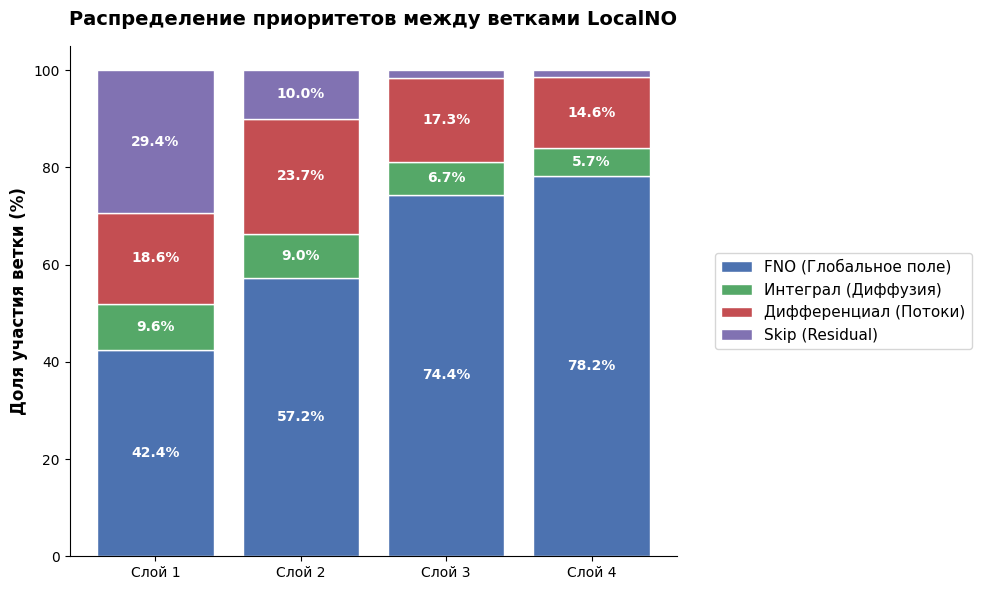

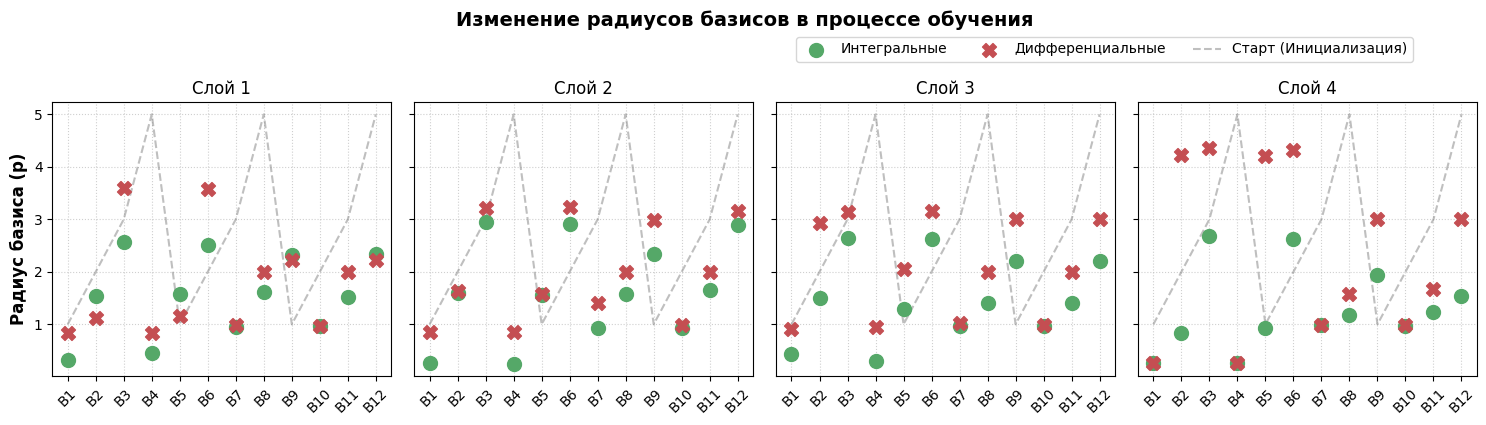


=== АНАЛИЗ РЕЗУЛЬТАТОВ НА ТЕСТЕ ===


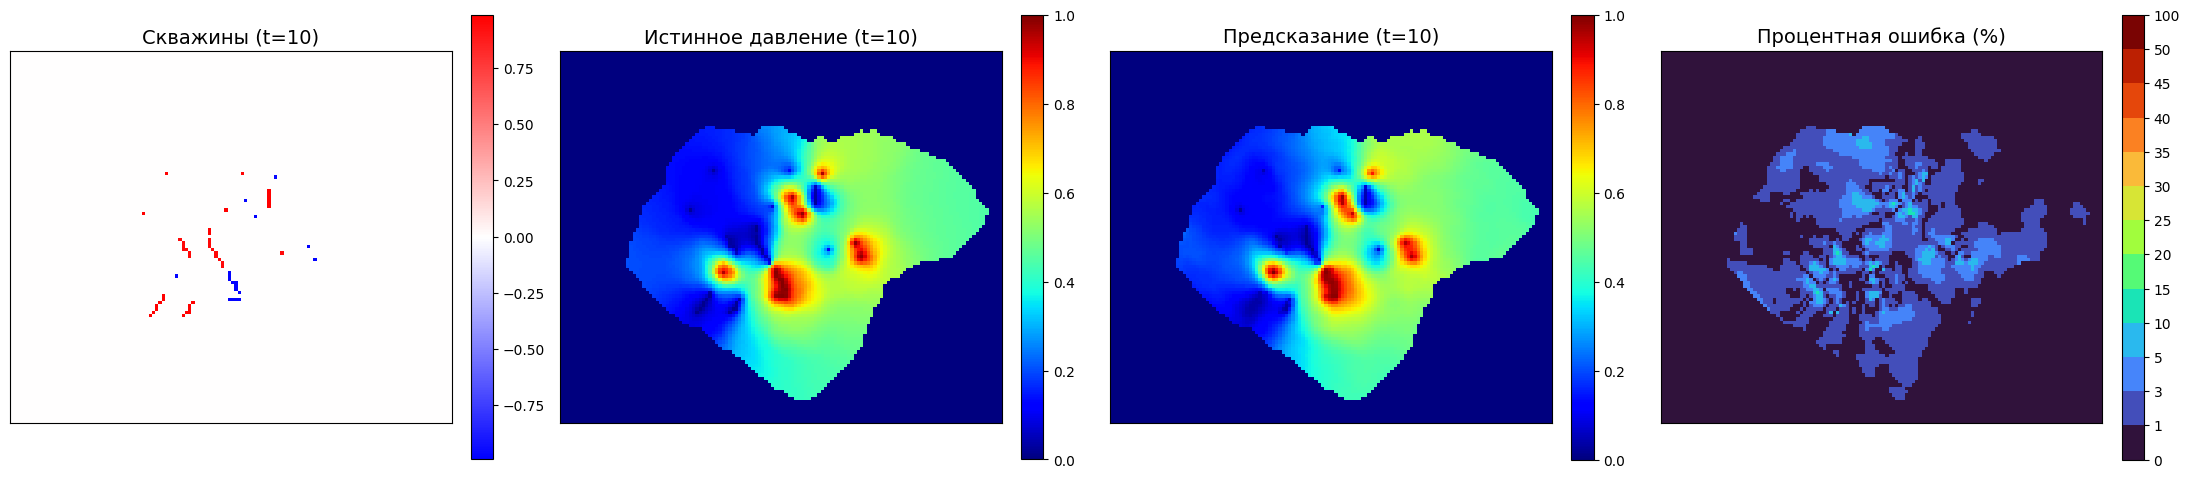

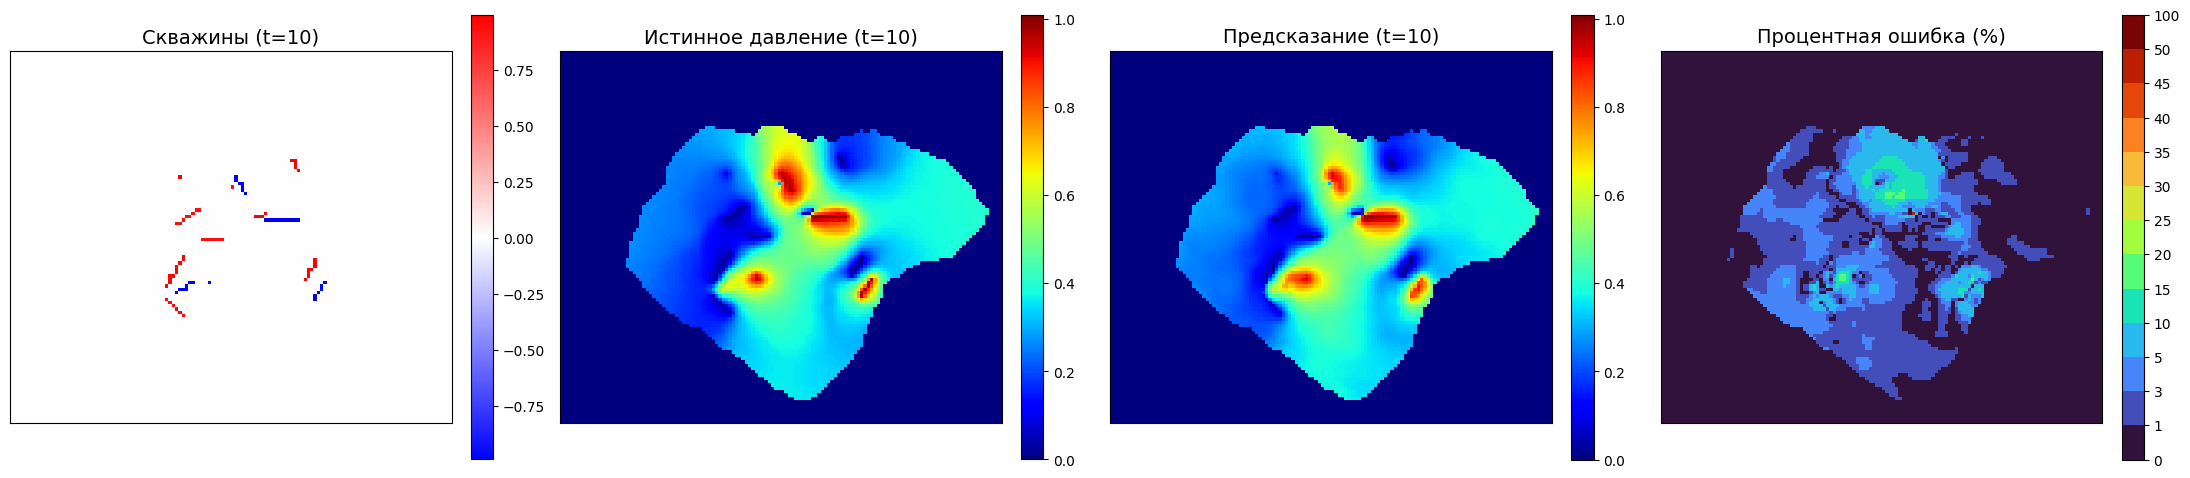

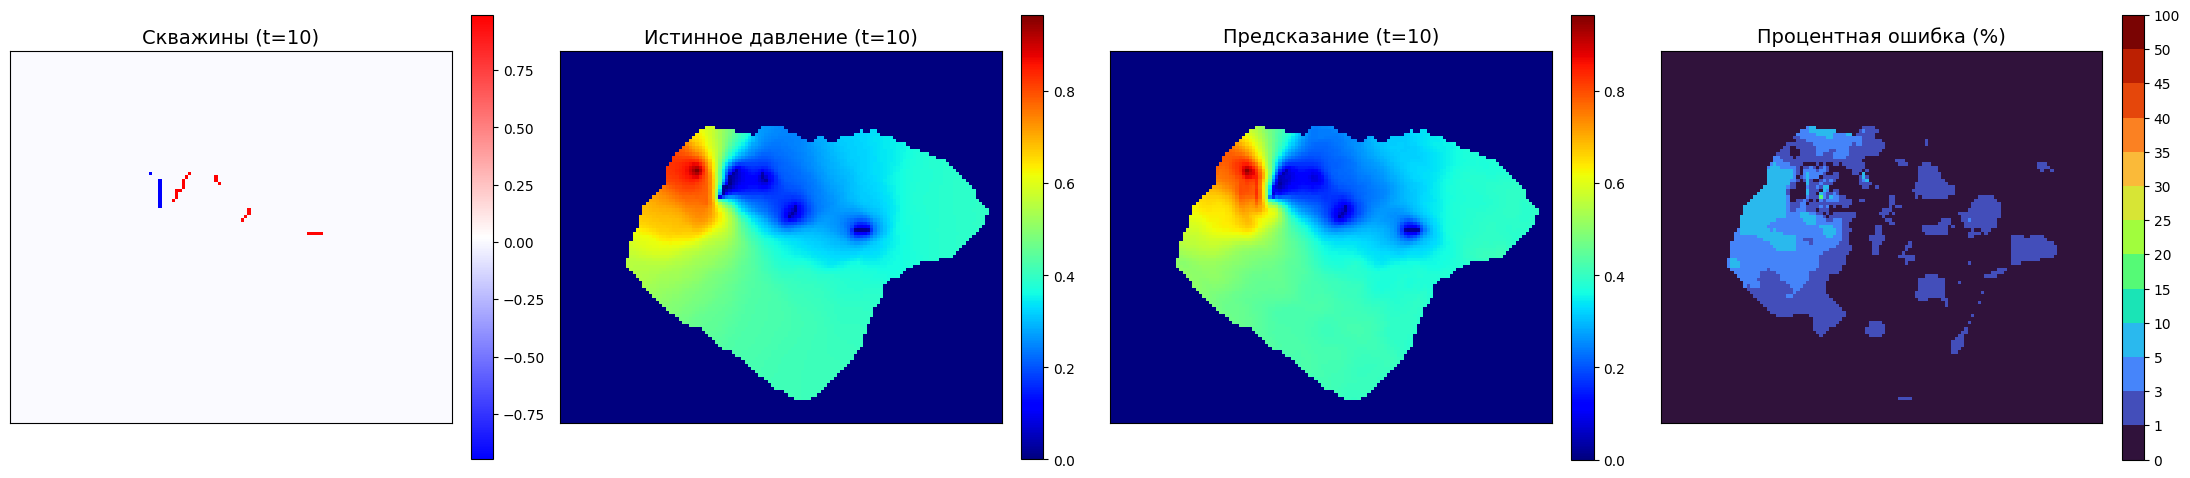

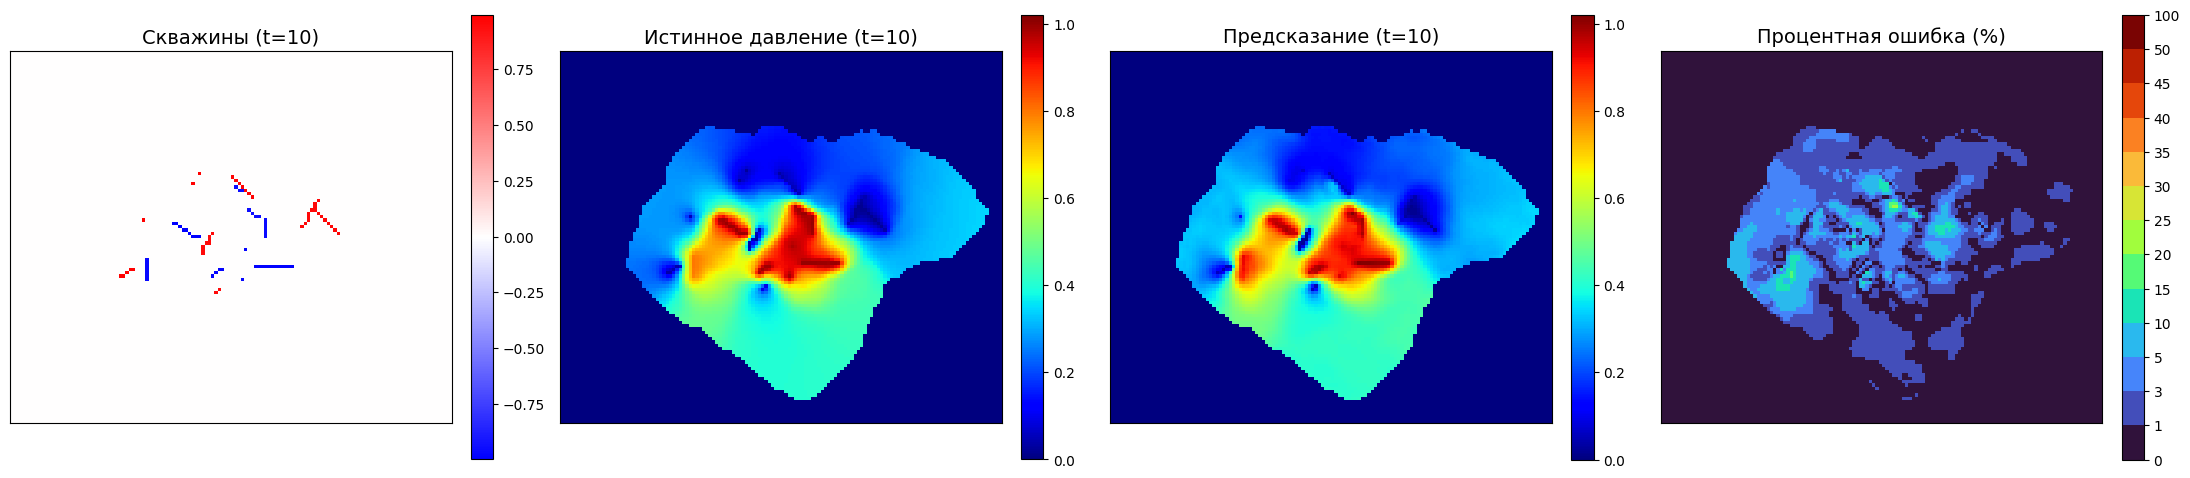

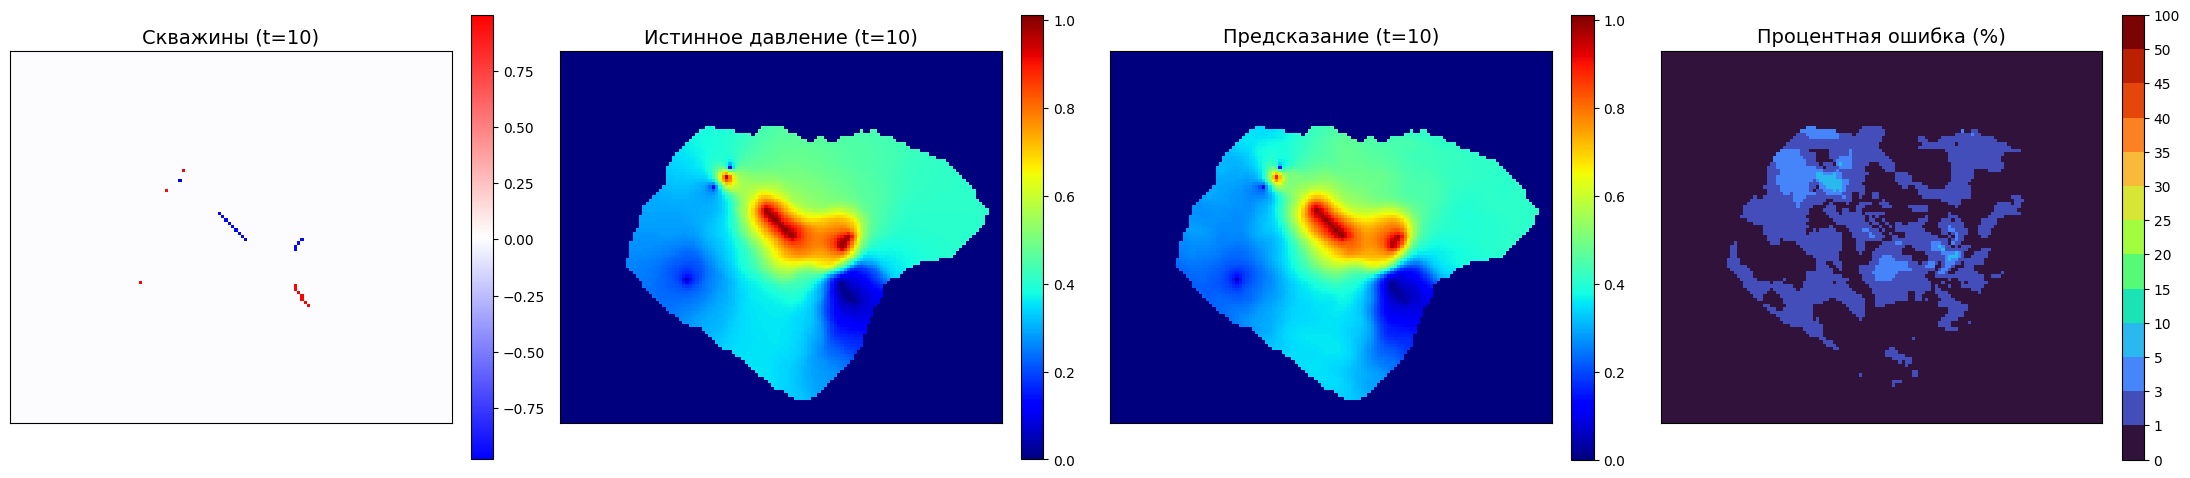

Средняя глобальная ошибка на тесте: 7.20%
Средняя ошибка В СКВАЖИНАХ на тесте: 10.21%

=== ГЕНЕРАЦИЯ GIF: SFNO_3D_rbf_b12.gif ===
Гифка сохранена как 'SFNO_3D_rbf_b12.gif'.


In [ ]:
GPU_ID = "cuda:2"
BASIS_TYPE = 'rbf'
NUM_BASES = 12
RADII = [1, 2, 3]
WELL_PENALTY = 10.0

MODES_3D = (10, 16, 16)
HIDDEN_CHANNELS = 64
N_LAYERS = 4
EPOCHS = 100
BATCH_SIZE = 2

device = GPU_ID if torch.cuda.is_available() else "cpu"

train_idx, val_idx, test_idx = get_indices(X_final.shape[0])


train_ds = SpatiotemporalDataset(X_final, train_idx)
val_ds = SpatiotemporalDataset(X_final, val_idx)
test_ds = SpatiotemporalDataset(X_final, test_idx)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

best_model = train_model(
    modes=MODES_3D, 
    hidden_channels=HIDDEN_CHANNELS, 
    n_layers=N_LAYERS,
    train_loader=train_loader, 
    val_loader=val_loader,
    static_mask=STATIC_MASK,
    device=device, 
    epochs=EPOCHS,
    well_penalty=WELL_PENALTY,
    radii=RADII,
    num_bases=NUM_BASES,
    basis_type=BASIS_TYPE
)

try:
    audit_piml_model(best_model)
except Exception as e:
    print(f"Ошибка при табличном выводе весов: {e}")


try:
    visualize_operator_weights(best_model)
except Exception as e:
    print(f"При при визуализации весов: {e}")

try:
    analyze_results(best_model, test_loader, device, STATIC_MASK, num_plots=5)
except Exception as e:
    print(f"Ошибка при отрисовке тепловых карт: {e}")